## `IMPORT LIBRARY & LOAD DATASET`

In [1]:
import numpy as np
import pandas as pd
import os
import nltk
import string
import re
import seaborn as sns

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix

from transformers import DistilBertModel
from transformers import AutoTokenizer
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader




[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-04-05 03:24:33.550912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775359473.748195      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775359473.809854      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775359474.293589      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775359474

In [2]:

BATCH_SIZE = 32
EPOCHS = 5

file_path = None

for dirname ,_ , filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.json'):
            file_path = os.path.join(dirname, filename)

print("file path:", file_path)
df = pd.read_json(file_path, lines = True)    

file path: /kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json


## `EDA`

1. Dataset overview
2. Category distribution
3. Text length distribution
5. Vocabulary analysis (size + richness by category + most frequent word + rare word)
6.  TF-IDF terms
7.   N-grams
8.   Category similarity

# 1. Dataset overview

In [3]:
df["text"] = df["headline"] + " " + df["short_description"]

print("Number of samples: ", len(df["text"]))
print("Number of categories: ", df["category"].nunique())

np.random.seed(42)
categories = df["category"].unique()
sample_categories = np.random.choice(categories,10,replace = False)
samples = []
for cat in sample_categories:
    sample = df[df["category"] == cat].sample(1)
    samples.append(sample)
    
sample_df = pd.concat(samples)
sample_df = sample_df.reset_index(drop = True)
print(sample_df[["category", "text"]])

Number of samples:  209527
Number of categories:  42
         category                                               text
0        RELIGION  Bowe Bergdahl's Pastor Explains His Faith Back...
1         SCIENCE  Eclipses in the October Skies When the Moon is...
2        POLITICS  The United Debacle Shows Airlines Have Given U...
3   LATINO VOICES  Gina Rodriguez Goes Full 'Fifty Shades Of Jane...
4  CULTURE & ARTS  Pieter Hugo on the ImageBlog Pieter Hugo From ...
5           FIFTY  Why Change Sucks Even When You're Middle Age C...
6    QUEER VOICES  Meet The Transgender Teen Heading To SCOTUS To...
7         COLLEGE  Class Clown to Class President There was alway...
8         PARENTS  Why I'm Proud of My Son's Low GPA Success to u...
9          SPORTS  The NFL, MLB and Viagra: So Much for Family-Fr...


# 2. Category distribution

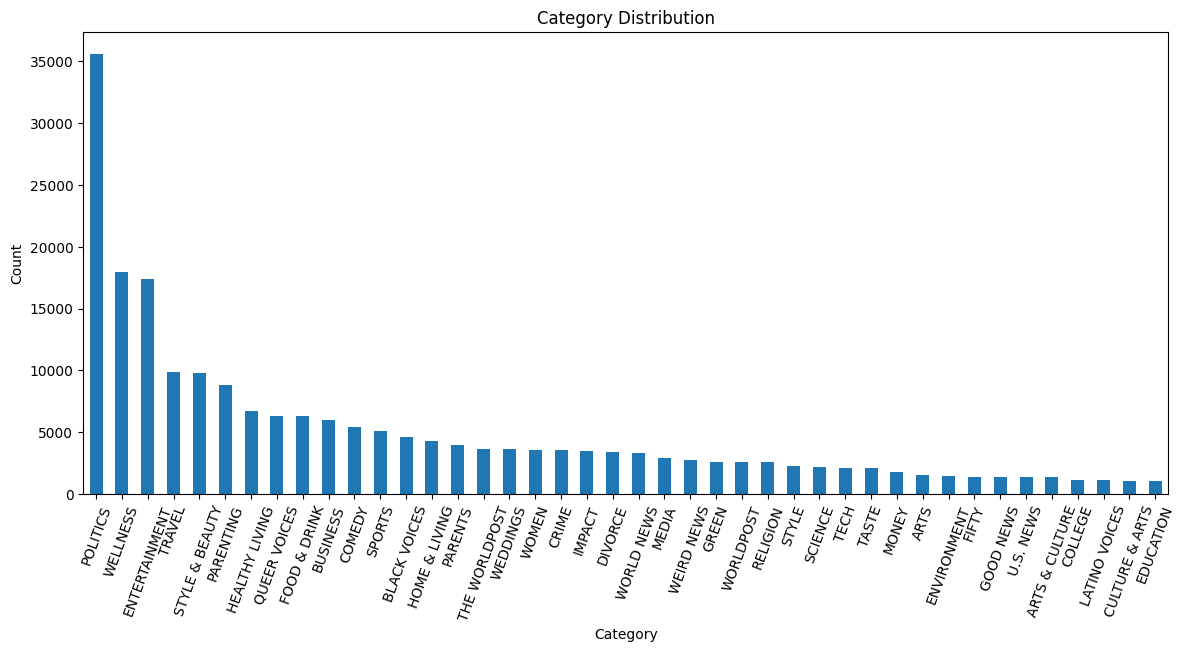

In [4]:
category_counts = df["category"].value_counts()

plt.figure(figsize = (14,6))
category_counts.plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.show()

# 3. Text length analysis

In [5]:
def raw_tokenize(text):
    return nltk.word_tokenize(text.lower())
    
def clean_tokenize(text):
    tokens = nltk.word_tokenize(text.lower())
    return [
        w for w in tokens
        if w not in stop_words
        and w not in string.punctuation
        and w.isalpha()
    ]

df["tokens"] = df["text"].apply(raw_tokenize)

all_words = [word for tokens in df["tokens"] for word in tokens]
vocab = set(all_words)

print("Vocabulary size:", len(vocab))

Vocabulary size: 120874


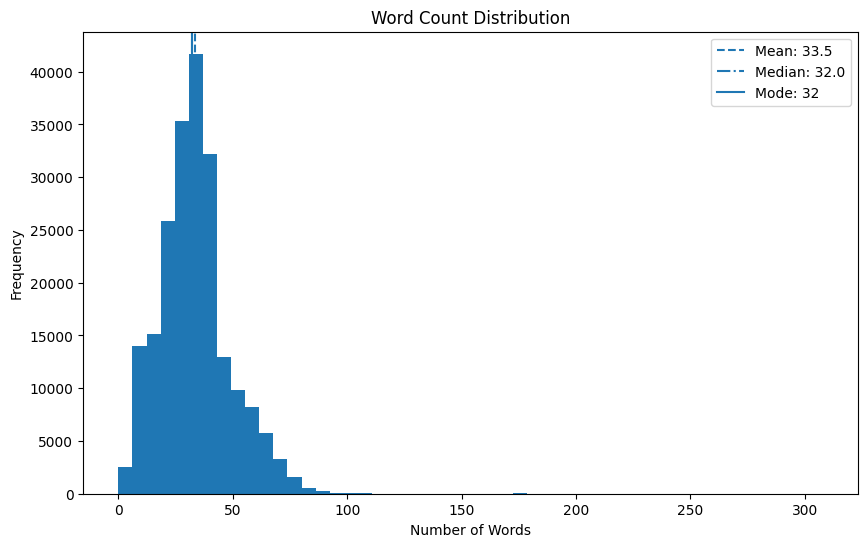

In [6]:
df["word_count"] = df["tokens"].apply(len)
mean = df["word_count"].mean()
median = df["word_count"].median()
mode = df["word_count"].mode()[0]

plt.figure(figsize=(10,6))
plt.hist(df["word_count"], bins=50)

# add lines
plt.axvline(mean, linestyle='--', label=f"Mean: {mean:.1f}")
plt.axvline(median, linestyle='-.', label=f"Median: {median}")
plt.axvline(mode, linestyle='-', label=f"Mode: {mode}")

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# 4. STOPWORDS ANALYSIS

In [7]:
stop_words = set(stopwords.words('english'))

counter = Counter(all_words)
total_words = sum(counter.values())
stopword_counts = {word: count for word, count in counter.items() if word in stop_words}
total_stopwords = sum(stopword_counts.values())

print("Total words:", total_words)
print("Total stopwords:", total_stopwords)
print("Stopword ratio:", total_stopwords / total_words)

Total words: 7025173
Total stopwords: 2464543
Stopword ratio: 0.35081598702266836


# STOPWORDS FREQUENCY 

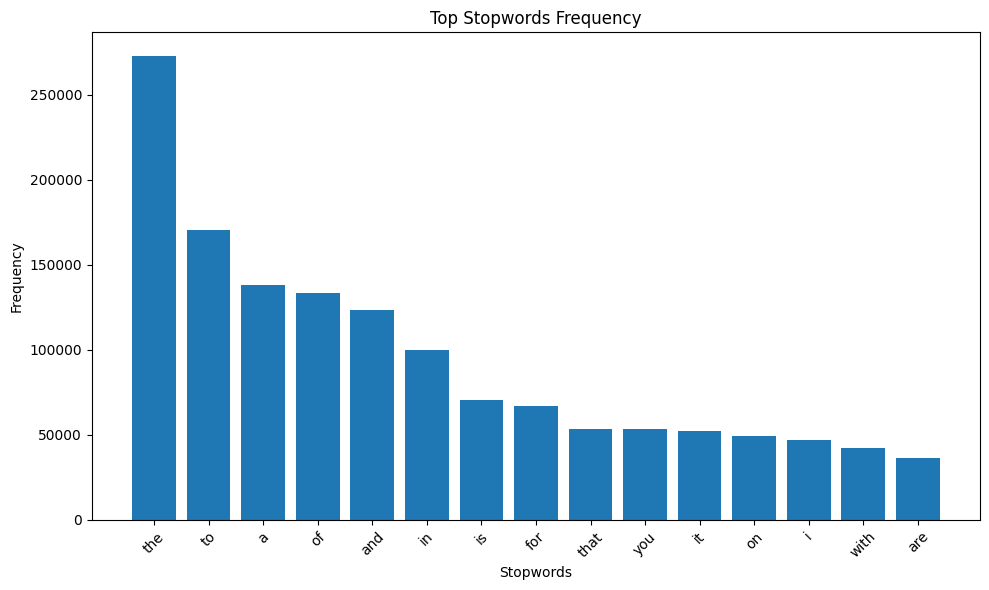

In [8]:
top_stopwords = sorted(stopword_counts.items(), key=lambda x: x[1], reverse=True)[:15]

# Unpack
words, counts = zip(*top_stopwords)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.title("Top Stopwords Frequency")
plt.xlabel("Stopwords")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 5. VOCABULARY ANALYSIS

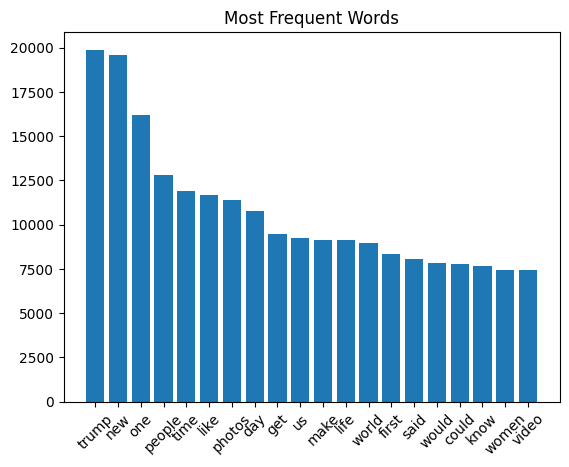

In [9]:
df["tokens"] = df["text"].apply(clean_tokenize)
df["clean_text"] = df["tokens"].apply(lambda tokens: " ".join(tokens))

all_words = [word for tokens in df["tokens"] for word in tokens]
vocab = set(all_words)

counter = Counter(all_words)

most_common = counter.most_common(20)

words, counts = zip(*most_common)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Most Frequent Words")
plt.show()

In [10]:
def vocab_stats(group):
    # flatten all tokens in this category
    all_words = [word for tokens in group["tokens"] for word in tokens]
    
    total_words = len(all_words)
    unique_words = len(set(all_words))
    articles = len(group)
    
    ttr = unique_words / total_words if total_words > 0 else 0
    
    return pd.Series({
        "Total Words": total_words,
        "Unique Words": unique_words,
        "TTR (%)": ttr * 100,
        "Articles": articles
    })

vocab_table = df.groupby("category").apply(vocab_stats)
vocab_table["TTR (%)"] = vocab_table["TTR (%)"].round(2)

print(vocab_table)

                Total Words  Unique Words  TTR (%)  Articles
category                                                    
ARTS                26057.0        8674.0    33.29    1509.0
ARTS & CULTURE      18539.0        6612.0    35.67    1339.0
BLACK VOICES        74328.0       12368.0    16.64    4583.0
BUSINESS           105662.0       15111.0    14.30    5992.0
COLLEGE             20157.0        5858.0    29.06    1144.0
COMEDY              72070.0       12619.0    17.51    5400.0
CRIME               53638.0       10146.0    18.92    3562.0
CULTURE & ARTS      21982.0        7769.0    35.34    1074.0
DIVORCE             62093.0        9443.0    15.21    3426.0
EDUCATION           20324.0        5668.0    27.89    1014.0
ENTERTAINMENT      239163.0       23400.0     9.78   17362.0
ENVIRONMENT         29331.0        7991.0    27.24    1444.0
FIFTY               29106.0        7222.0    24.81    1401.0
FOOD & DRINK        94055.0       12939.0    13.76    6340.0
GOOD NEWS           1757

/tmp/ipykernel_55/2990300124.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vocab_table = df.groupby("category").apply(vocab_stats)


# TF-IDF top terms

In [11]:
vectorizer = TfidfVectorizer(max_features=5000)

X_tfidf = vectorizer.fit_transform(df["clean_text"])

feature_names = np.array(vectorizer.get_feature_names_out())

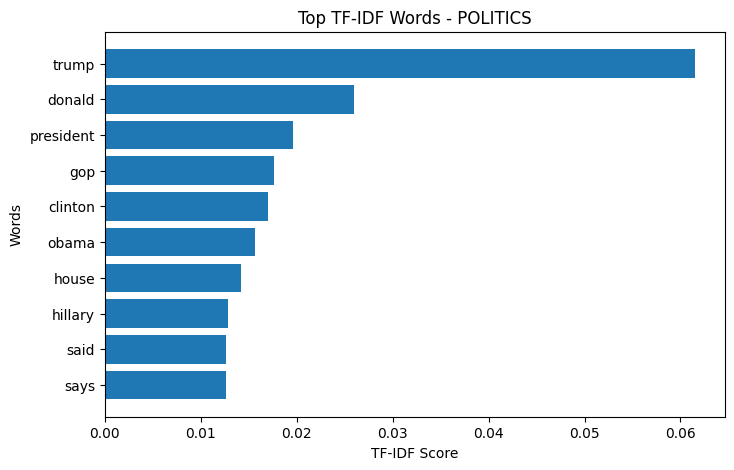

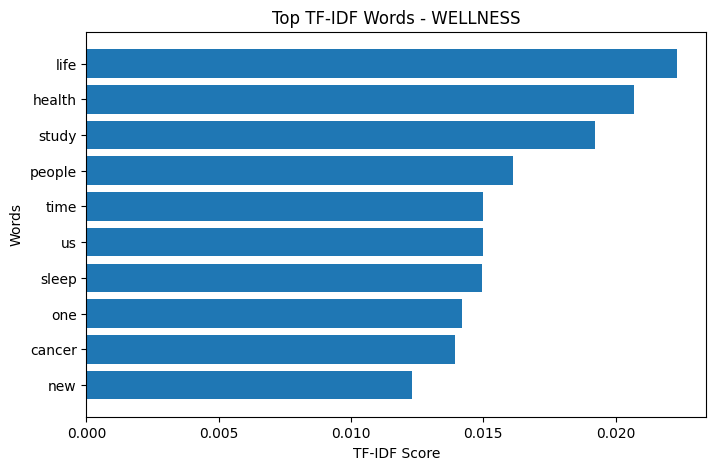

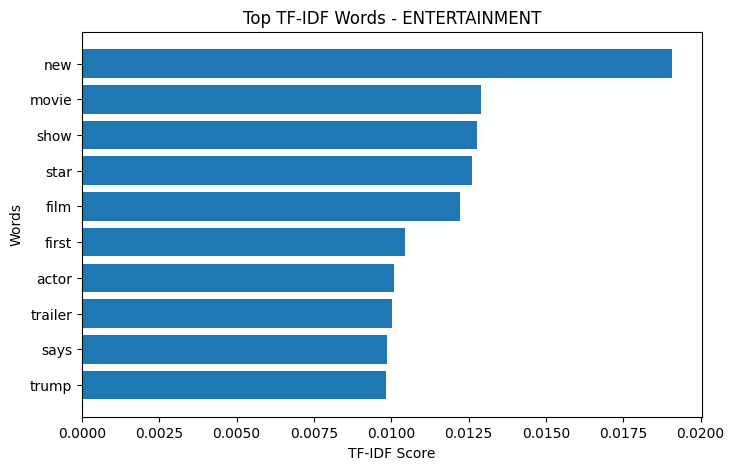

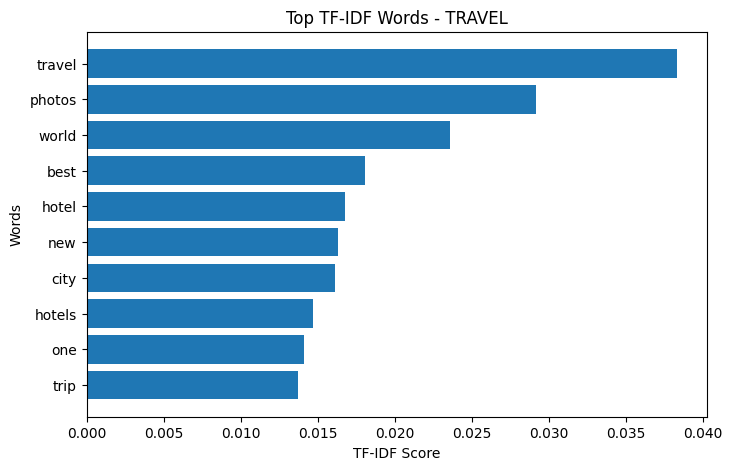

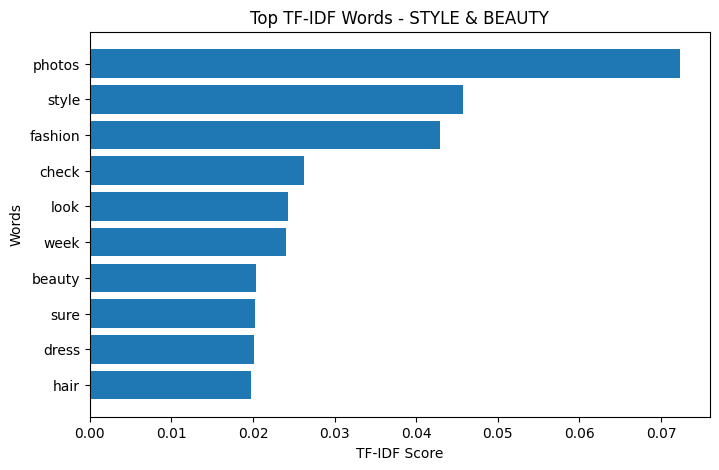

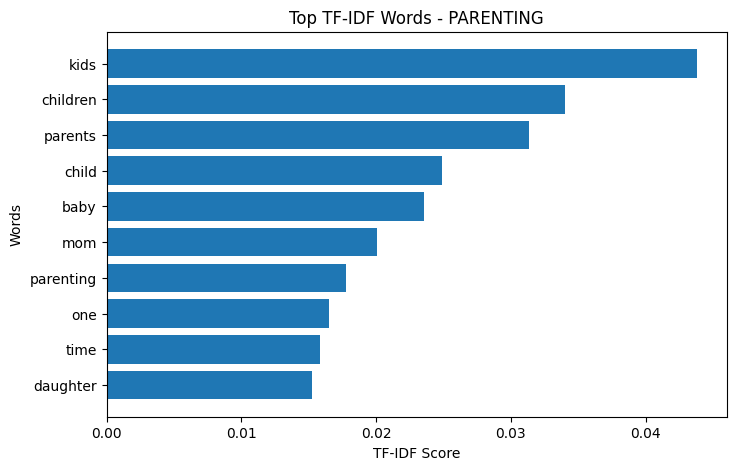

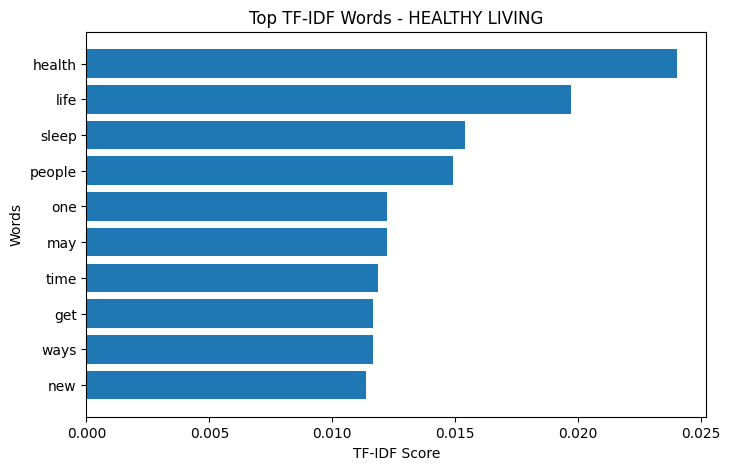

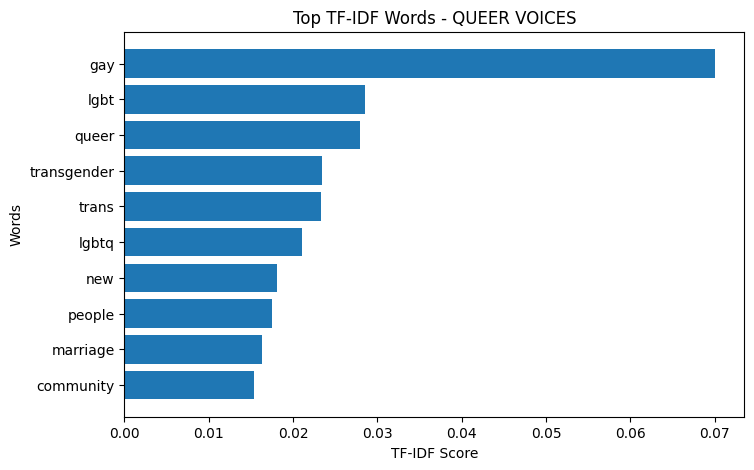

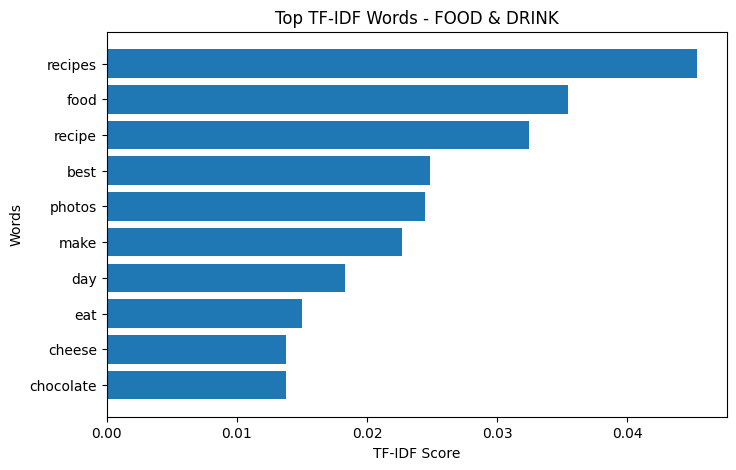

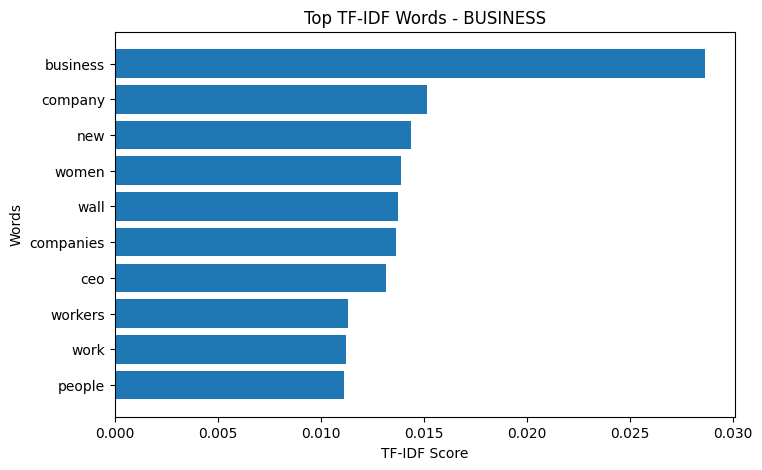

In [12]:
def plot_tfidf_terms_per_class(X, y, feature_names, top_n=10):
    top_categories = df["category"].value_counts().index[:10]
    for category in top_categories:
        idx = np.where(y == category)
        mean_tfidf = X[idx].mean(axis=0).A1
        
        top_indices = np.argsort(mean_tfidf)[-top_n:][::-1]
        
        top_words = [feature_names[i] for i in top_indices]
        top_scores = [mean_tfidf[i] for i in top_indices]
        
        plt.figure(figsize=(8, 5))
        plt.barh(top_words, top_scores)
        plt.gca().invert_yaxis()  # highest on top
        
        plt.title(f"Top TF-IDF Words - {category}")
        plt.xlabel("TF-IDF Score")
        plt.ylabel("Words")
plot_tfidf_terms_per_class(X_tfidf, df["category"].values, feature_names)

# Meaningful phrase pattern

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1, 3))  

X_ngram = vectorizer.fit_transform(df["clean_text"])
feature_names = vectorizer.get_feature_names_out()

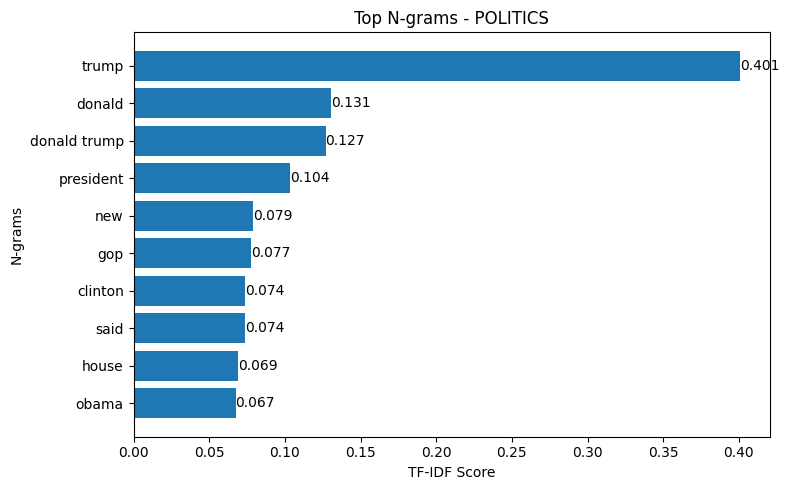

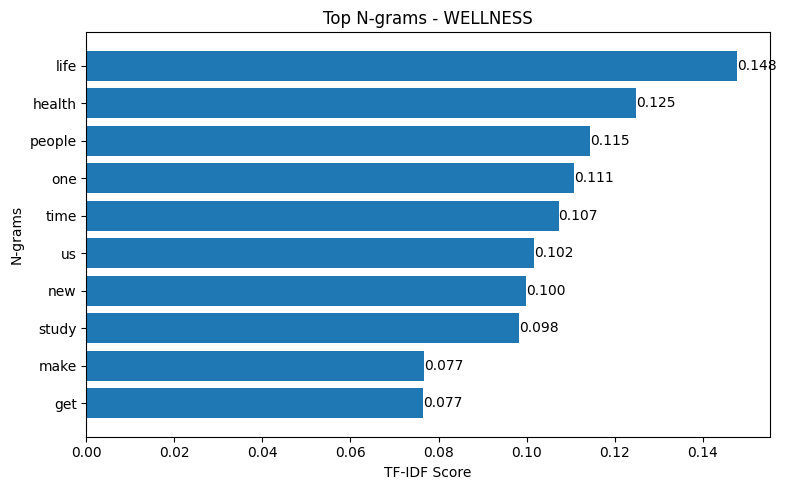

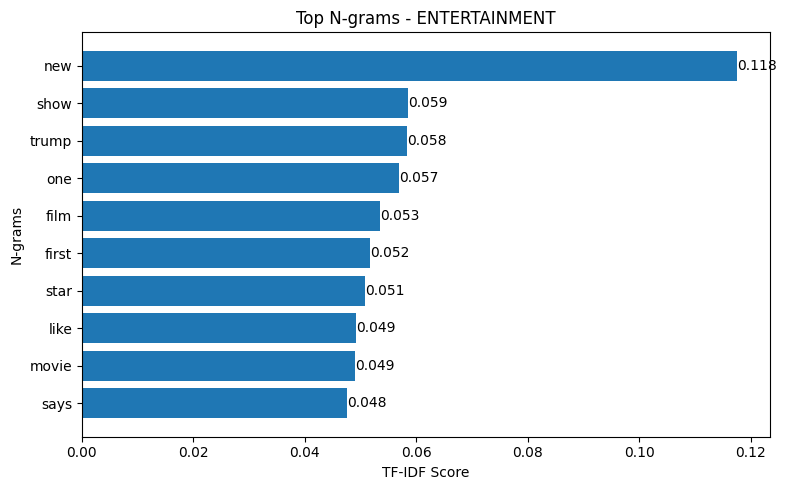

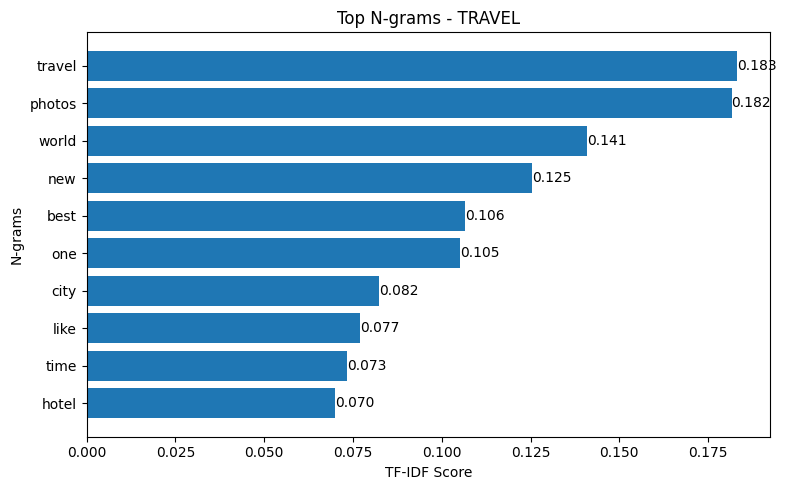

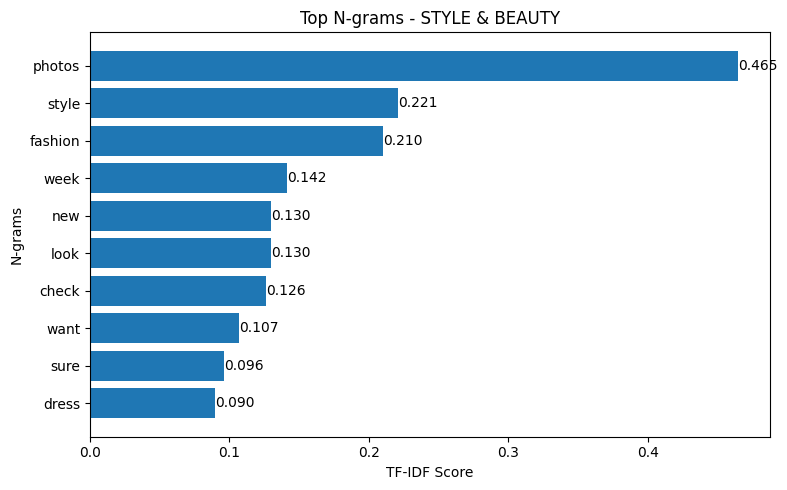

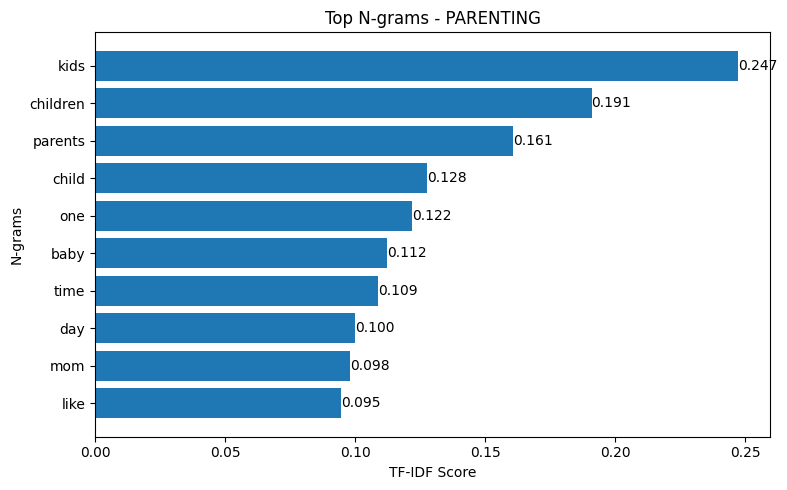

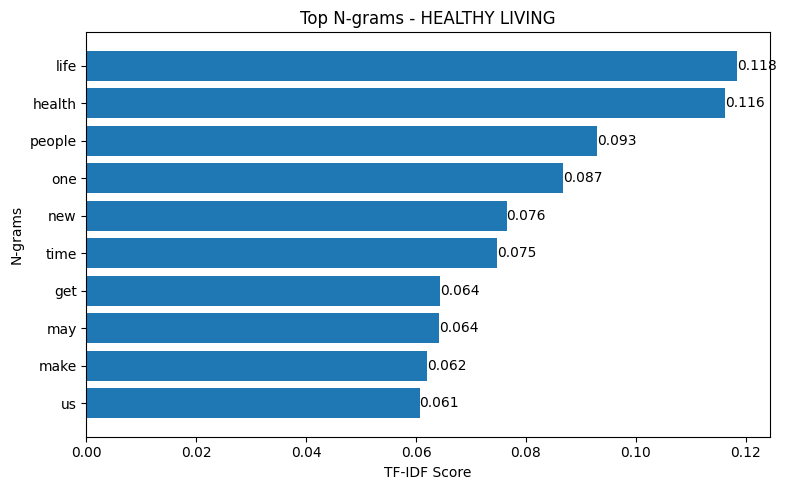

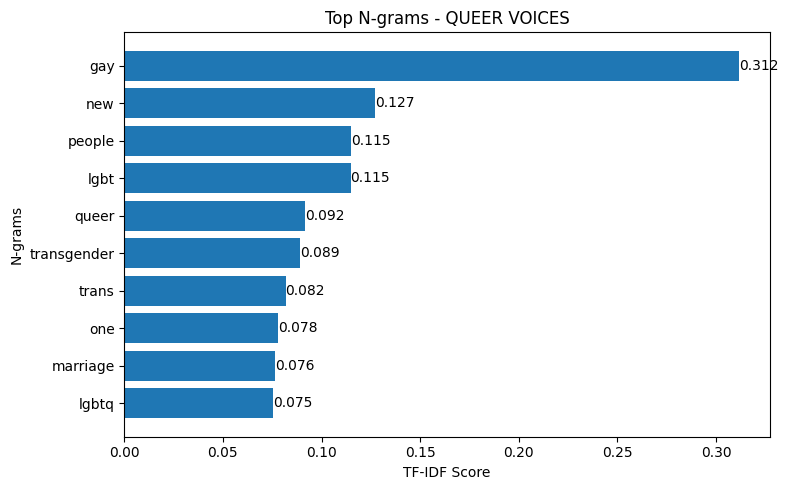

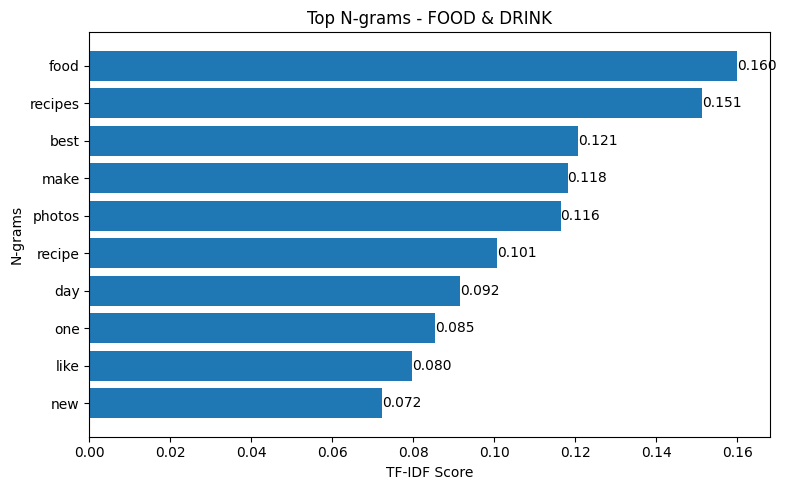

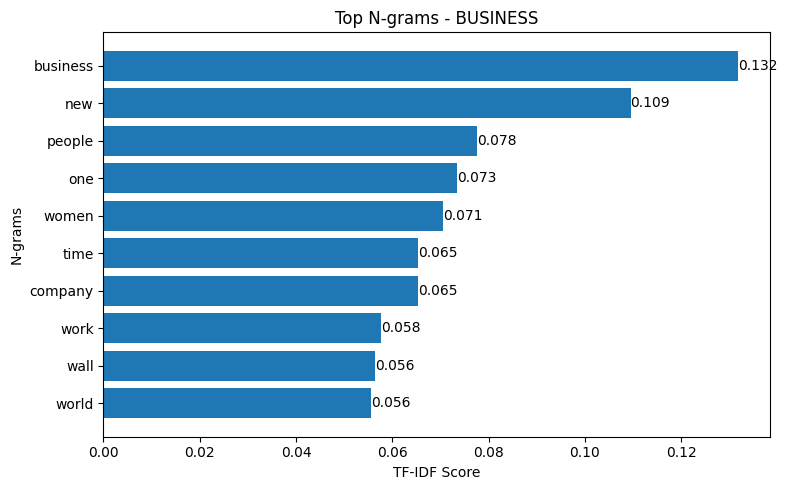

In [14]:
def plot_ngrams_per_category(X, y, feature_names, top_n=10):
    categories = np.unique(y)
    top_categories = df["category"].value_counts().index[:10]
    for category in top_categories:
        idx = np.where(y == category)[0]
        
        # extract sub-matrix
        X_cat = X[idx]
        
        # mean TF-IDF
        mean_scores = np.asarray(X_cat.mean(axis=0)).ravel()
        
        # keep non-zero only
        nonzero = mean_scores > 0
        filtered_scores = mean_scores[nonzero]
        filtered_features = feature_names[nonzero]
        
        # top N
        top_indices = np.argsort(filtered_scores)[-top_n:][::-1]
        
        top_words = [filtered_features[i] for i in top_indices]
        top_scores = [filtered_scores[i] for i in top_indices]
        
        # PLOT 
        plt.figure(figsize=(8,5))
        plt.barh(top_words, top_scores)
        plt.gca().invert_yaxis()  # highest on top
        
        plt.title(f"Top N-grams - {category}")
        plt.xlabel("TF-IDF Score")
        plt.ylabel("N-grams")
        
        # add values on bars
        for i, v in enumerate(top_scores):
            plt.text(v, i, f"{v:.3f}", va='center')
        
        plt.tight_layout()
        plt.show()

plot_ngrams_per_category(
    X_ngram,
    df["category"].values,
    feature_names
)

# 6. Category similarity

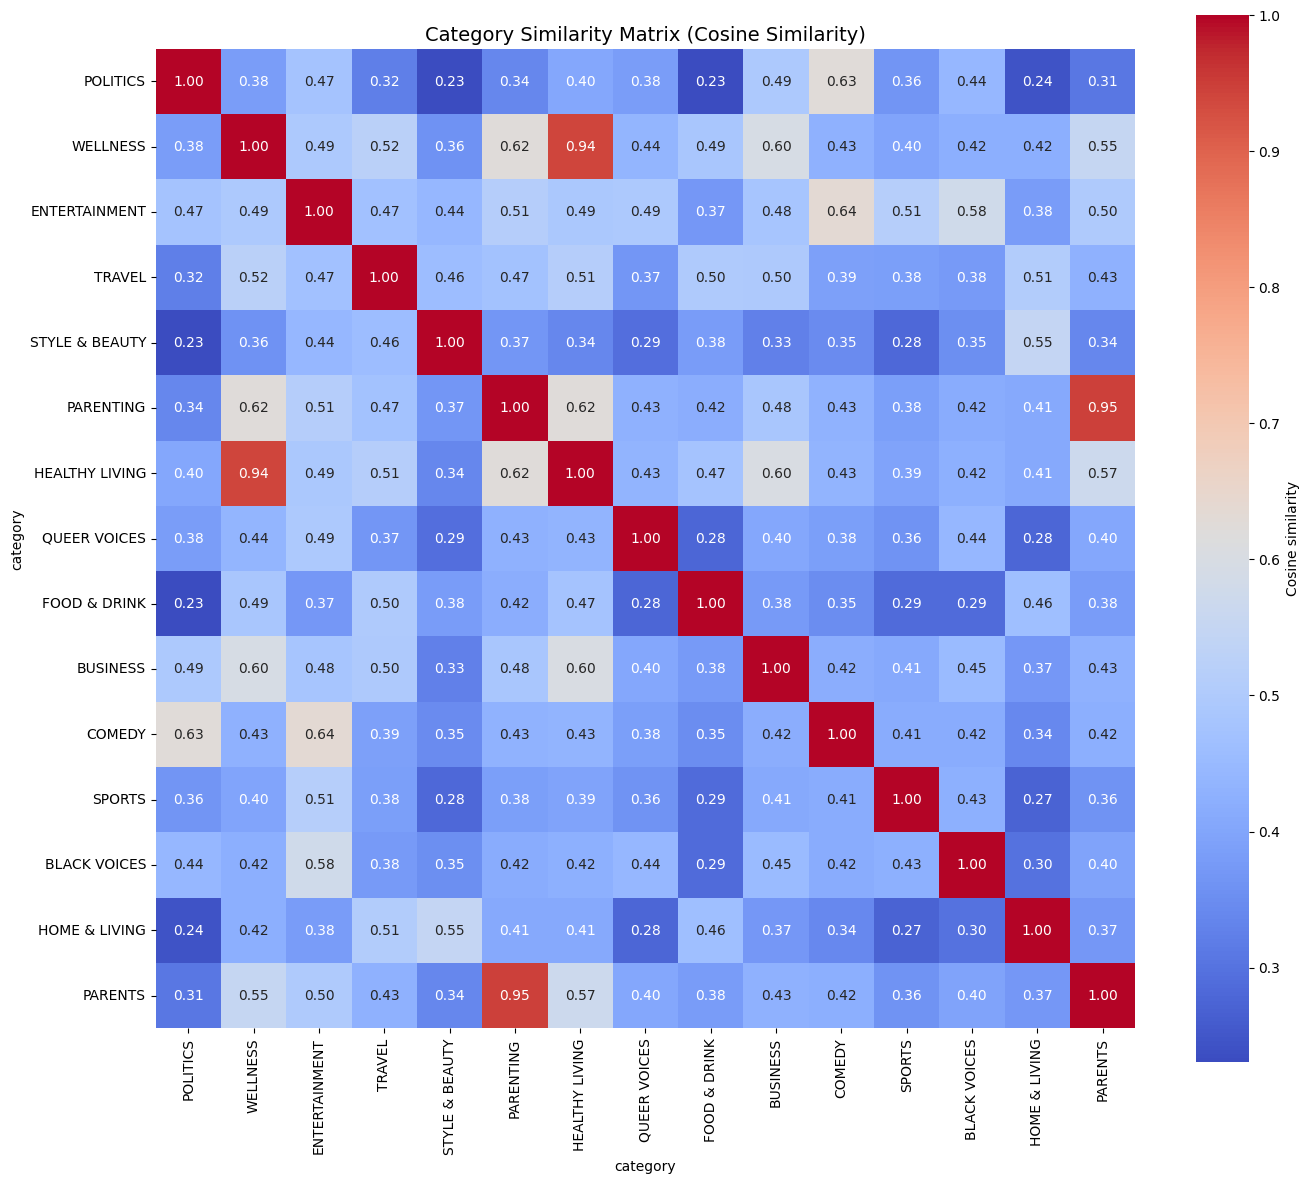

In [15]:

top_categories = df["category"].value_counts().index[:15]
df_top = df[df["category"].isin(top_categories)]

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df_top["clean_text"])

categories = df_top["category"].values

category_vectors = []

for cat in top_categories:
    idx = np.where(categories == cat)[0]
    category_vector = np.asarray(X[idx].mean(axis=0)).flatten()
    category_vectors.append(category_vector)

category_matrix = np.vstack(category_vectors)
sim = cosine_similarity(category_matrix)

sim_df = pd.DataFrame(
    sim,
    index=top_categories,
    columns=top_categories
)

plt.figure(figsize=(14,12))

sns.heatmap(
    sim_df,
    cmap="coolwarm",
    annot=True,        
    fmt=".2f",         
    square=True,
    cbar_kws={"label": "Cosine similarity"}
)

plt.title("Category Similarity Matrix (Cosine Similarity)", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## `PREPROCESSING`

# CHOOSING SUBSET

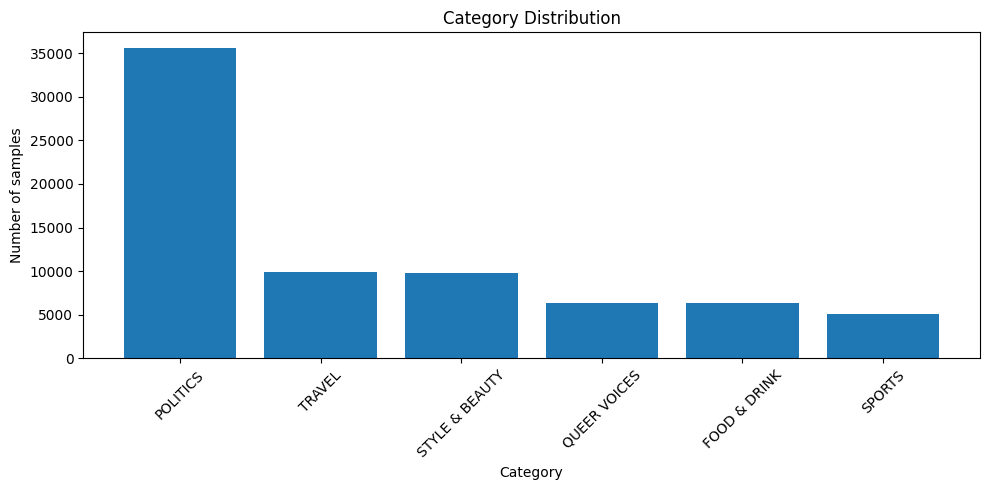

In [16]:
CATEGORIES = [
    "POLITICS",
    "TRAVEL",
    "STYLE & BEAUTY",
    "QUEER VOICES",
    "FOOD & DRINK",
    "SPORTS",
]
df = df[df["category"].isin(CATEGORIES)].copy()
df = df.reset_index(drop=True)   # clean 0-based index

counts = df["category"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of samples")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TOKENIZATION

In [17]:
def clean_text(text):
    text = text.lower()  # lowercase
    
    # remove punctuation + numbers
    text = re.sub(r"[^\w\s]", " ", text)   # remove punctuation
    text = re.sub(r"\d+", " ", text)       # remove numbers
    
    tokens = word_tokenize(text)
    
    # remove extra spaces + short tokens
    tokens = [t for t in tokens if len(t) > 1]
    
    return tokens

df["tokens"] = df["text"].apply(clean_text)

# LABEL ENCODING

In [18]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["category"])
num_classes = len(le.classes_)
print(dict(zip(le.classes_, range(num_classes))))

{'FOOD & DRINK': 0, 'POLITICS': 1, 'QUEER VOICES': 2, 'SPORTS': 3, 'STYLE & BEAUTY': 4, 'TRAVEL': 5}


# VOCABULARY BUILD

In [19]:
all_tokens = [word for tokens in df["tokens"] for word in tokens]
counter = Counter(all_tokens)

# remove rare words 
min_freq = 2

filtered_words = [(w, c) for w, c in counter.items() if c >= min_freq]
filtered_words = sorted(filtered_words, key=lambda x: x[1], reverse=True)

PAD = 0
OOV = 1

vocab = {"<PAD>": PAD, "<OOV>": OOV}

for i, (word, _) in enumerate(filtered_words):
    vocab[word] = i + 2

vocab_size = len(vocab)
input_size = vocab_size

print("Vocab size:", vocab_size)

Vocab size: 33464


# ENCODING

In [20]:
def encode(tokens):
    return [
        vocab.get(word, OOV)
        for word in tokens
    ]

df["seq"] = df["tokens"].apply(encode)

# PADDING

In [21]:
max_len = 60  # tune this

x = pad_sequences(
    df["seq"],
    maxlen=max_len,
    padding="post",
    truncating="post"
)
y = df["label"].values


# TRAIN/VAL/TEST SPLIT

In [22]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x,y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)
x_test, x_val, y_test, y_val = train_test_split(
    x_temp,y_temp,
    test_size = 0.5,
    random_state = 42,
    stratify = y_temp
)

In [23]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [24]:
train_loader = DataLoader(TextDataset(x_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TextDataset(x_val, y_val), batch_size=32)
test_loader  = DataLoader(TextDataset(x_test, y_test), batch_size=32)

# SIMPLE RNN

In [25]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

In [26]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [27]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_size,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)

        # better than out[:, -1, :]
        forward = out[:, -1, :self.lstm.hidden_size]
        backward = out[:, 0, self.lstm.hidden_size:]
        out = torch.cat((forward, backward), dim=1)

        return self.fc(out)

In [74]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, train_loader, val_loader, device, epochs=5, lr=1e-3):
    model.to(device)
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    criterion  = nn.CrossEntropyLoss()
    params_m   = count_parameters(model) / 1e6
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ── train ──────
        model.train()
        correct, total = 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            preds    = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
        train_acc = correct / total

        # ── validation ──────
        model.eval()                     
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs  = model(X_batch)
                preds    = torch.argmax(outputs, dim=1)
                correct += (preds == y_batch).sum().item()
                total   += y_batch.size(0)
        val_acc = correct / total

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    # ── inference speed ────
    model.eval()
    total_time, total_samples = 0.0, 0

    with torch.no_grad():
        for i, (X_batch, _) in enumerate(val_loader):
            X_batch = X_batch.to(device)

            if i == 0:                   
                _ = model(X_batch)
                continue

            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.time()
            _     = model(X_batch)
            if device.type == "cuda":
                torch.cuda.synchronize()
            total_time    += time.time() - start
            total_samples += X_batch.size(0)

    inference_ms = (total_time / total_samples) * 1000

    print("\n===== MODEL METRICS =====")
    print(f"Params:    {params_m:.2f} M")
    print(f"Inference: {inference_ms:.4f} ms/sample")

    return train_accs, val_accs, params_m, inference_ms

In [75]:
def plot_acc(train_accs, val_accs, title="Accuracy"):
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(val_accs, label="Val Accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [76]:
def plot_model_efficiency(models, params_m, inference_ms):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Params
    ax[0].bar(models, params_m)
    ax[0].set_title("Model Size (Params)")
    ax[0].set_ylabel("Millions")
    ax[0].tick_params(axis='x', rotation=30)

    # Inference
    ax[1].bar(models, inference_ms)
    ax[1].set_title("Inference Speed")
    ax[1].set_ylabel("ms/sample")
    ax[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

In [77]:
def run_experiment(model_class, name):

    model = model_class(
        vocab_size=len(vocab),
        embed_dim=128,
        hidden_size=128,
        num_classes=len(set(y))
    ).to(device)

    train_accs, val_accs, params_m, inference_ms = train_model(
        model,
        train_loader,
        val_loader,
        device=device,
        epochs=EPOCHS
    )

    plot_acc(train_accs, val_accs, name)

    return model, train_accs, val_accs, params_m, inference_ms

Epoch 1: Train Acc=0.4867, Val Acc=0.4872
Epoch 2: Train Acc=0.4882, Val Acc=0.4870
Epoch 3: Train Acc=0.4900, Val Acc=0.4868
Epoch 4: Train Acc=0.4923, Val Acc=0.4866
Epoch 5: Train Acc=0.4936, Val Acc=0.4866

===== MODEL METRICS =====
Params:    4.32 M
Inference: 0.0118 ms/sample


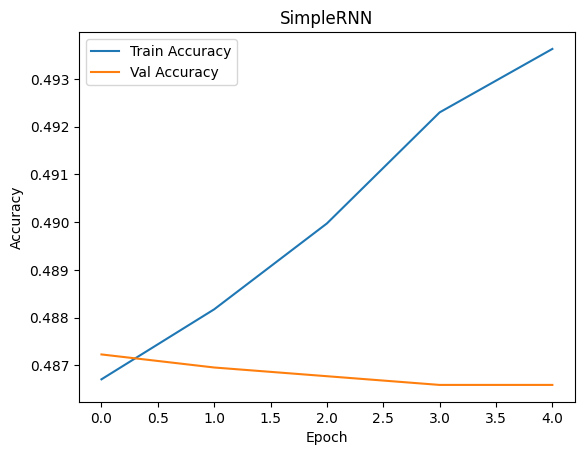

Epoch 1: Train Acc=0.5763, Val Acc=0.6784
Epoch 2: Train Acc=0.7899, Val Acc=0.8609
Epoch 3: Train Acc=0.9089, Val Acc=0.8892
Epoch 4: Train Acc=0.9454, Val Acc=0.8992
Epoch 5: Train Acc=0.9672, Val Acc=0.8924

===== MODEL METRICS =====
Params:    4.42 M
Inference: 0.0174 ms/sample


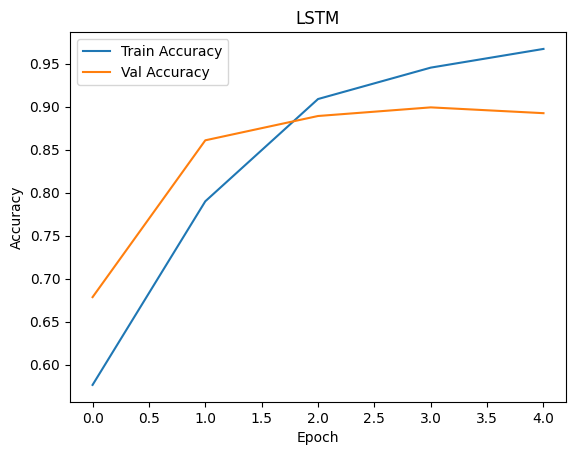

Epoch 1: Train Acc=0.7677, Val Acc=0.8497
Epoch 2: Train Acc=0.9097, Val Acc=0.8949
Epoch 3: Train Acc=0.9509, Val Acc=0.8989
Epoch 4: Train Acc=0.9729, Val Acc=0.9012
Epoch 5: Train Acc=0.9870, Val Acc=0.8994

===== MODEL METRICS =====
Params:    4.55 M
Inference: 0.0286 ms/sample


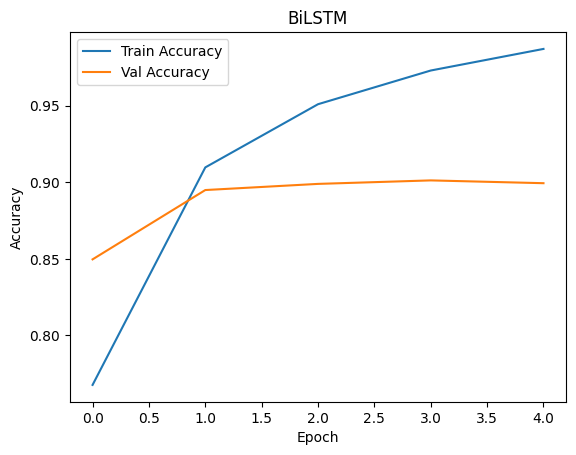

In [78]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rnn_model, rnn_train_accs, rnn_val_accs, rnn_params, rnn_infer = run_experiment(SimpleRNN, "SimpleRNN")

lstm_model, lstm_train_accs, lstm_val_accs, lstm_params, lstm_infer = run_experiment(LSTM, "LSTM")

bilstm_model, bilstm_train_accs, bilstm_val_accs, bilstm_params, bilstm_infer = run_experiment(BiLSTM, "BiLSTM")

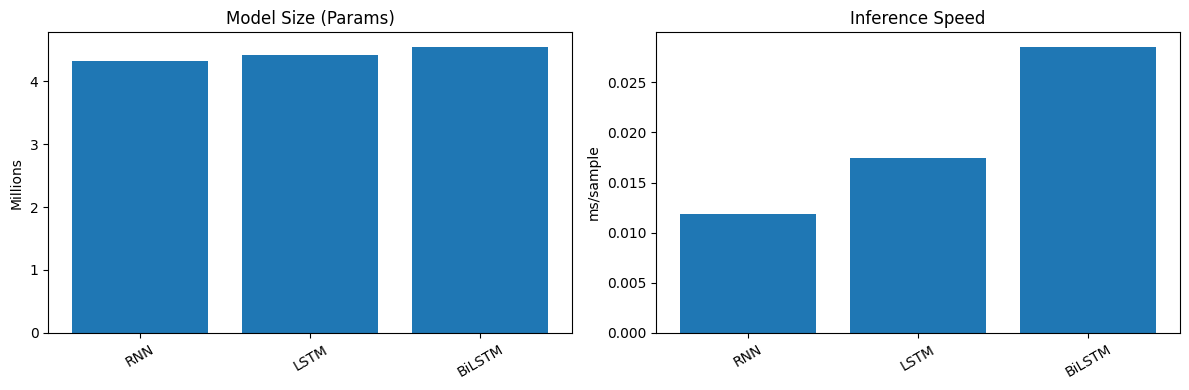

In [79]:
models = ["RNN", "LSTM", "BiLSTM"]
params = [rnn_params, lstm_params, bilstm_params]
inference = [rnn_infer, lstm_infer, bilstm_infer]

plot_model_efficiency(models, params, inference)

In [80]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

In [81]:
from transformers import DistilBertModel

class DistilBERTClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")

        for param in self.bert.parameters():
            param.requires_grad = False

        hidden_size = self.bert.config.hidden_size
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        mask = attention_mask.unsqueeze(-1)
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        return self.fc(pooled)

In [82]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_transformer(
    model,
    train_loader,
    val_loader,
    device,
    forward_fn,
    epochs=3,
    lr=2e-5
):

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_accs = []
    val_accs = []

    # PARAMETER COUNT
    params_m = count_parameters(model) / 1e6

    print("Starting training...")

    for epoch in range(epochs):

        print(f"\n===== Epoch {epoch+1}/{epochs} =====")

        # ---------------- TRAIN ----------------
        model.train()
        correct, total = 0, 0

        loop = tqdm(train_loader, desc="Training")

        for batch in loop:

            optimizer.zero_grad()

            outputs, labels = forward_fn(model, batch, device)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        train_acc = correct / total
        train_accs.append(train_acc)

        print(f"📊 Train Acc: {train_acc:.4f}")

        # ---------------- VALIDATION ----------------
        if val_loader is not None:

            model.eval()
            correct, total = 0, 0

            with torch.no_grad():
                for batch in tqdm(val_loader, desc="Validation"):

                    outputs, labels = forward_fn(model, batch, device)

                    preds = outputs.argmax(dim=1)
                    correct += (preds == labels).sum().item()
                    total += labels.size(0)

            val_acc = correct / total
            val_accs.append(val_acc)

            print(f"📊 Val Acc: {val_acc:.4f}")

    print("\nTraining complete!")

    # INFERENCE TIME 
    model.eval()

    total_time = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in val_loader:

            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()

            outputs, labels = forward_fn(model, batch, device)

            if device.type == "cuda":
                torch.cuda.synchronize()
            end = time.perf_counter()

            total_time += (end - start)
            total_samples += labels.size(0)

    inference_ms = (total_time / total_samples) * 1000

    # PRINT METRICS
    print("\n===== MODEL METRICS =====")
    print(f"Params: {params_m:.2f} M")
    print(f"Inference: {inference_ms:.4f} ms/sample")

    return model, train_accs, val_accs, params_m, inference_ms

## DistilBERT TRAIN/TEST/VAL 

In [83]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

texts = df["text"].tolist()
labels = df["category"].tolist()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
x_train, x_temp, y_train, y_temp = train_test_split(
    texts, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

x_test, x_val, y_test, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)
train_encodings = tokenizer(
    x_train,
    padding=True,
    truncation=True,
    max_length=128
)


val_encodings = tokenizer(
    x_val,
    padding=True,
    truncation=True,
    max_length=128
)

test_encodings = tokenizer(
    x_test,
    padding=True,
    truncation=True,
    max_length=128
)

train_dataset = TextDataset(train_encodings, y_train)
val_dataset   = TextDataset(val_encodings, y_val)
test_dataset  = TextDataset(test_encodings, y_test)


In [84]:

from torch.utils.data import DataLoader

def distil_forward(model, batch, device):
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    if isinstance(outputs, tuple):
        outputs = outputs[0]

    return outputs, labels


train_loader_distil = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader_distil = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader_distil = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

distil_model = DistilBERTClassifier(num_classes=len(set(y)))

distil_model, train_accs, val_accs, params_m, inference_ms = train_transformer(
    distil_model,
    train_loader_distil,
    val_loader_distil,
    device,
    forward_fn=distil_forward
)

print("\n== DISTILBERT RESULT ==")
print(f"Params (M): {params_m:.2f}")
print(f"Inference (ms/sample): {inference_ms:.4f}")
print(f"Final Val Acc: {val_accs[-1]:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training...

===== Epoch 1/3 =====


Training: 100%|██████████| 3198/3198 [03:42<00:00, 14.40it/s, loss=0.58] 


📊 Train Acc: 0.5608


...

📊 Val Acc: 0.8285

===== Epoch 3/3 =====


Training: 100%|██████████| 3198/3198 [03:41<00:00, 14.45it/s, loss=0.751]


📊 Train Acc: 0.8435


Validation: 100%|██████████| 686/686 [00:46<00:00, 14.63it/s]


📊 Val Acc: 0.8619

Training complete!

===== MODEL METRICS =====
Params: 0.00 M
Inference: 4.1707 ms/sample

== DISTILBERT RESULT ==
Params (M): 0.00
Inference (ms/sample): 4.1707
Final Val Acc: 0.8619


## `Evaluation`

In [85]:
def evaluate_rnn_model(model, dataloader, device):

    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(y_batch.cpu().numpy())

    acc = accuracy_score(labels_list, preds_list)
    f1 = f1_score(labels_list, preds_list, average="weighted", zero_division=0)

    return acc, f1

In [86]:
def evaluate_transformer(model, dataloader, device):

    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = torch.argmax(outputs, dim=1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_list, preds_list)
    f1 = f1_score(labels_list, preds_list, average="weighted", zero_division=0)

    return acc, f1

In [87]:
rnn_acc, rnn_f1 = evaluate_rnn_model(rnn_model, test_loader, device)
lstm_acc, lstm_f1 = evaluate_rnn_model(lstm_model, test_loader, device)
bilstm_acc, bilstm_f1 = evaluate_rnn_model(bilstm_model, test_loader, device)
distil_acc, distil_f1 = evaluate_transformer(distil_model,test_loader_distil,device)

In [88]:
results = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "BiLSTM", "DistilBERT"],
    "Accuracy": [rnn_acc, lstm_acc, bilstm_acc,distil_acc],
    "F1-score": [rnn_f1, lstm_f1, bilstm_f1, distil_f1]
})

# Sort by F1-score (recommended)
results = results.sort_values(by="F1-score", ascending=False)

# Print clean table
print(results.to_string(index=False))

     Model  Accuracy  F1-score
    BiLSTM  0.902208  0.902145
      LSTM  0.891717  0.892782
DistilBERT  0.860609  0.852209
 SimpleRNN  0.484309  0.321302


In [89]:
from sklearn.metrics import confusion_matrix
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(
    model,
    dataloader,
    device,
    class_names,
    normalize=False,
    title="Confusion Matrix"
):
    model.eval()
    preds = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:  # ✅ fixed indentation

            # 🔥 Case 1: BERT-style (dict)
            if isinstance(batch, dict):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                y_batch = batch["labels"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)

                # HuggingFace output
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits

            # 🔥 Case 2: RNN/LSTM (tuple)
            else:
                X_batch, y_batch = batch
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

            pred = torch.argmax(outputs, dim=1)

            preds.extend(pred.detach().cpu().numpy())
            labels.extend(y_batch.detach().cpu().numpy())

    # Build confusion matrix
    cm = confusion_matrix(
        labels,
        preds,
        labels=list(range(len(class_names)))
    )

    # Normalize if needed
    if normalize:
        cm = cm.astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm = cm / row_sums

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        square=True,
        cbar=True
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

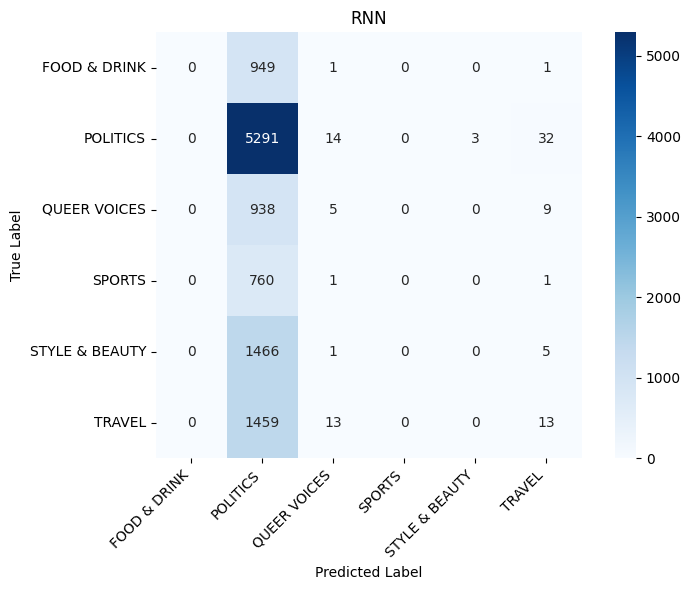

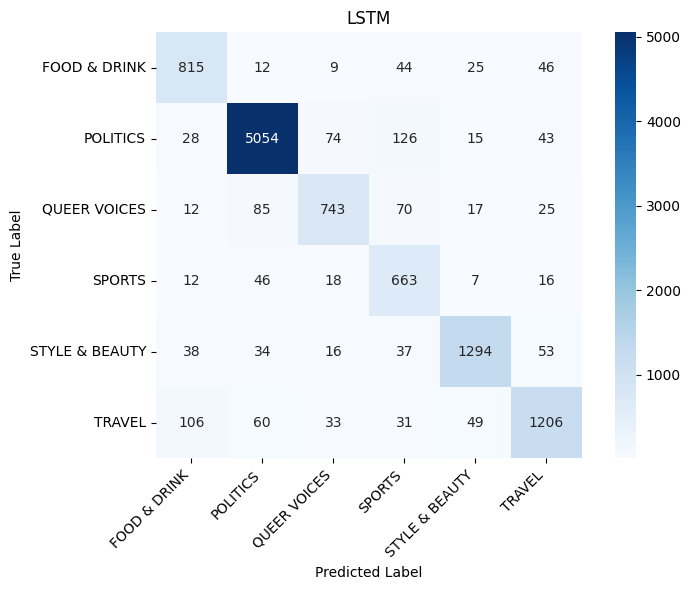

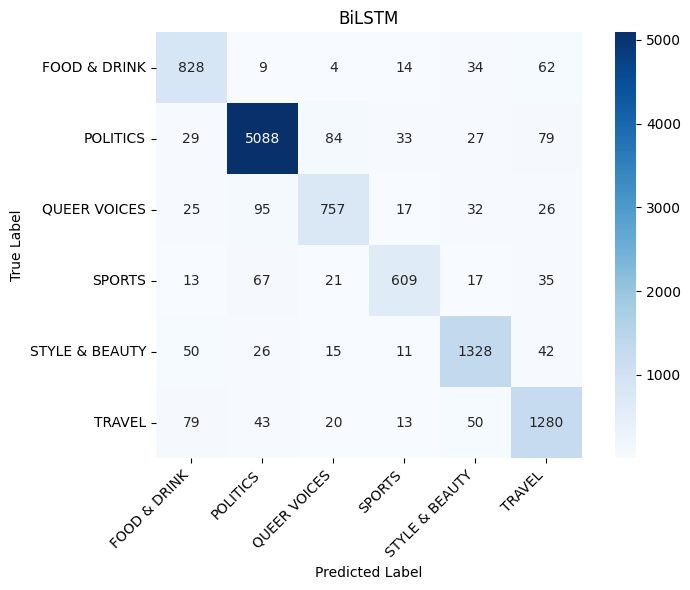

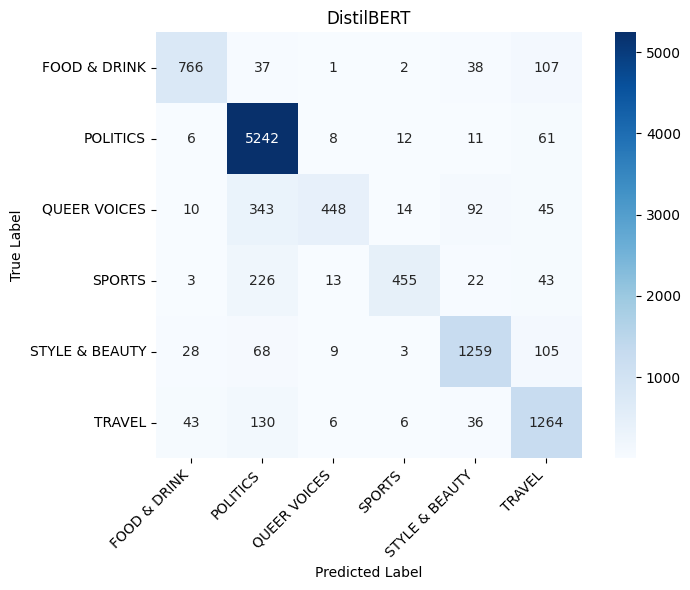

In [90]:
class_names = list(le.classes_)
# RNN family
plot_confusion_matrix(rnn_model, test_loader, device, class_names, title="RNN")
plot_confusion_matrix(lstm_model, test_loader, device, class_names, title="LSTM")
plot_confusion_matrix(bilstm_model, test_loader, device, class_names, title="BiLSTM")
# Transformer
plot_confusion_matrix(distil_model, test_loader_distil, device, class_names, title="DistilBERT")

## `APPENDIX`

# FOCAL LOSS

In [91]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# TRAIN RNN - FOCAL LOSS

In [92]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, train_loader, val_loader, device, epochs=5, lr=1e-3):
    model.to(device)
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    criterion = FocalLoss(gamma=2.0, alpha=0.25)
    params_m   = count_parameters(model) / 1e6
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ── train ──────
        model.train()
        correct, total = 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            preds    = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
        train_acc = correct / total

        # ── validation ──────
        model.eval()                     
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs  = model(X_batch)
                preds    = torch.argmax(outputs, dim=1)
                correct += (preds == y_batch).sum().item()
                total   += y_batch.size(0)
        val_acc = correct / total

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    # ── inference speed ────
    model.eval()
    total_time, total_samples = 0.0, 0

    with torch.no_grad():
        for i, (X_batch, _) in enumerate(val_loader):
            X_batch = X_batch.to(device)

            if i == 0:                   
                _ = model(X_batch)
                continue

            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.time()
            _     = model(X_batch)
            if device.type == "cuda":
                torch.cuda.synchronize()
            total_time    += time.time() - start
            total_samples += X_batch.size(0)

    inference_ms = (total_time / total_samples) * 1000

    print("\n===== MODEL METRICS =====")
    print(f"Params:    {params_m:.2f} M")
    print(f"Inference: {inference_ms:.4f} ms/sample")

    return train_accs, val_accs, params_m, inference_ms

# TRAIN TRANSFORMER  - FOCAL LOSS

In [93]:
def train_transformer(
    model,
    train_loader,
    val_loader,
    device,
    forward_fn,
    epochs=3,
    lr=2e-5
):

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = FocalLoss(gamma=2.0, alpha=0.25)

    train_accs = []
    val_accs = []

    print("Starting training...")

    for epoch in range(epochs):

        print(f"\n===== Epoch {epoch+1}/{epochs} =====")

        # ---------------- TRAIN ----------------
        model.train()
        correct, total, total_loss = 0, 0, 0

        loop = tqdm(train_loader, desc="Training")

        for batch in loop:

            optimizer.zero_grad()

            outputs, labels = forward_fn(model, batch, device)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        train_acc = correct / total
        train_accs.append(train_acc)

        print(f"📊 Train Acc: {train_acc:.4f}")

        # ---------------- VALIDATION ----------------
        if val_loader is not None:

            model.eval()
            correct, total = 0, 0

            with torch.no_grad():
                for batch in tqdm(val_loader, desc="Validation"):

                    outputs, labels = forward_fn(model, batch, device)

                    preds = outputs.argmax(dim=1)

                    correct += (preds == labels).sum().item()
                    total += labels.size(0)

            val_acc = correct / total
            val_accs.append(val_acc)

            print(f"📊 Val Acc: {val_acc:.4f}")

    print("\n Training complete!")

    return model, train_accs, val_accs

Epoch 1: Train Acc=0.4861, Val Acc=0.4870
Epoch 2: Train Acc=0.4876, Val Acc=0.4882
Epoch 3: Train Acc=0.4873, Val Acc=0.4870
Epoch 4: Train Acc=0.4887, Val Acc=0.4868
Epoch 5: Train Acc=0.4905, Val Acc=0.4870

===== MODEL METRICS =====
Params:    4.32 M
Inference: 0.0132 ms/sample


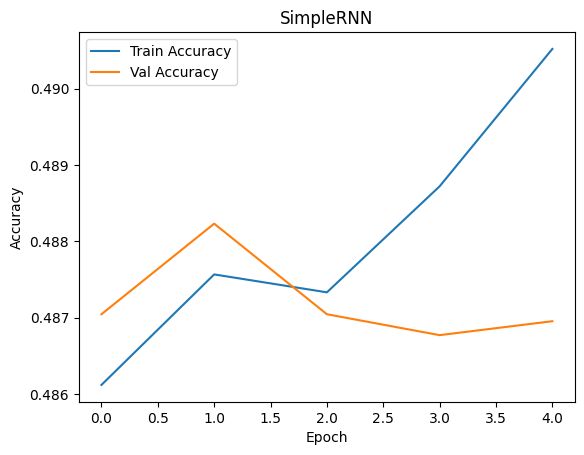

Epoch 1: Train Acc=0.5926, Val Acc=0.7182
Epoch 2: Train Acc=0.8184, Val Acc=0.8624
Epoch 3: Train Acc=0.9091, Val Acc=0.8852
Epoch 4: Train Acc=0.9457, Val Acc=0.8891
Epoch 5: Train Acc=0.9655, Val Acc=0.8892

===== MODEL METRICS =====
Params:    4.42 M
Inference: 0.0177 ms/sample


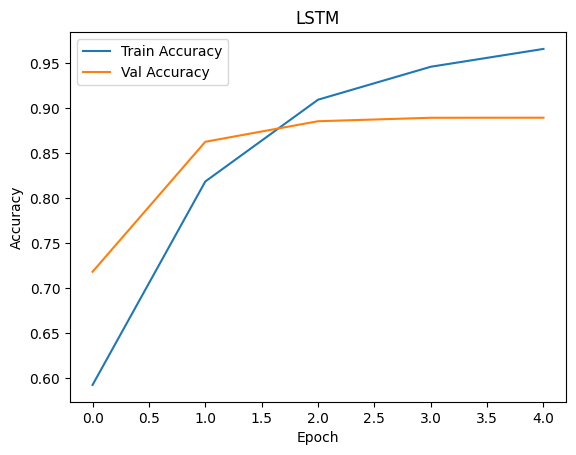

Epoch 1: Train Acc=0.7677, Val Acc=0.8562
Epoch 2: Train Acc=0.9050, Val Acc=0.8867
Epoch 3: Train Acc=0.9502, Val Acc=0.8919
Epoch 4: Train Acc=0.9736, Val Acc=0.8880
Epoch 5: Train Acc=0.9836, Val Acc=0.8959

===== MODEL METRICS =====
Params:    4.55 M
Inference: 0.0282 ms/sample


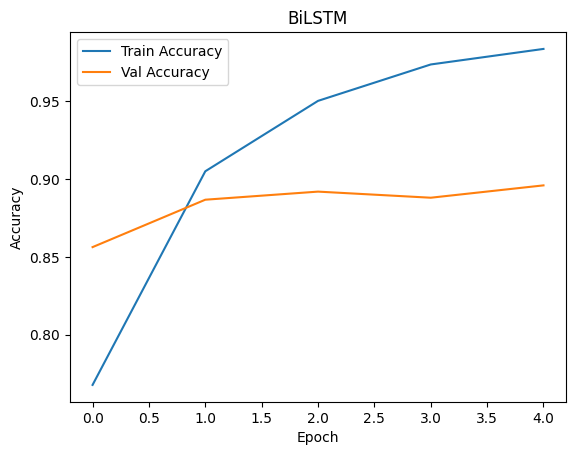

In [94]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rnn_model, rnn_train_accs, rnn_val_accs, rnn_params, rnn_infer = run_experiment(SimpleRNN, "SimpleRNN")

lstm_model, lstm_train_accs, lstm_val_accs, lstm_params, lstm_infer = run_experiment(LSTM, "LSTM")

bilstm_model, bilstm_train_accs, bilstm_val_accs, bilstm_params, bilstm_infer = run_experiment(BiLSTM, "BiLSTM")

In [95]:
distil_model = DistilBERTClassifier(num_classes=len(set(y)))

distil_model, train_accs, val_accs = train_transformer(
    distil_model,
    train_loader_distil,
    val_loader_distil,   
    device,
    forward_fn=distil_forward
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training...

===== Epoch 1/3 =====


Training: 100%|██████████| 3198/3198 [03:42<00:00, 14.35it/s, loss=0.16]  


📊 Train Acc: 0.6158


...

📊 Val Acc: 0.8570

===== Epoch 3/3 =====


Training: 100%|██████████| 3198/3198 [03:43<00:00, 14.34it/s, loss=0.0263]


📊 Train Acc: 0.8648


Validation: 100%|██████████| 686/686 [00:47<00:00, 14.57it/s]

📊 Val Acc: 0.8770

 Training complete!


In [96]:
rnn_focal_acc, rnn_focal_f1 = evaluate_rnn_model(rnn_model, test_loader, device)
lstm_focal_acc, lstm_focal_f1 = evaluate_rnn_model(lstm_model, test_loader, device)
bilstm_focal_acc, bilstm_focal_f1 = evaluate_rnn_model(bilstm_model, test_loader, device)
distil_focal_acc, distil_focal_f1 = evaluate_transformer(distil_model,test_loader_distil,device)

In [98]:
results = pd.DataFrame({
    "Model": [
        "SimpleRNN", "SimpleRNN (Focal)",
        "LSTM", "LSTM (Focal)",
        "BiLSTM", "BiLSTM (Focal)",
        "DistilBERT", "DistilBERT (Focal)"
    ],
    "Loss": [
        "CrossEntropy", "Focal",
        "CrossEntropy", "Focal",
        "CrossEntropy", "Focal",
        "CrossEntropy", "Focal"
    ],
    "Accuracy": [
        rnn_acc, rnn_focal_acc,
        lstm_acc, lstm_focal_acc,
        bilstm_acc, bilstm_focal_acc,
        distil_acc, distil_focal_acc
    ],
    "F1-score": [
        rnn_f1, rnn_focal_f1,
        lstm_f1, lstm_focal_f1,
        bilstm_f1, bilstm_focal_f1,
        distil_f1, distil_focal_f1
    ]
})

print(results.to_string(index=False))

             Model         Loss  Accuracy  F1-score
         SimpleRNN CrossEntropy  0.484309  0.321302
 SimpleRNN (Focal)        Focal  0.485039  0.321010
              LSTM CrossEntropy  0.891717  0.892782
      LSTM (Focal)        Focal  0.891078  0.891343
            BiLSTM CrossEntropy  0.902208  0.902145
    BiLSTM (Focal)        Focal  0.893450  0.892230
        DistilBERT CrossEntropy  0.860609  0.852209
DistilBERT (Focal)        Focal  0.875753  0.872122



  Experiment: Exp 1 — Downsampling only (max_len=60)
Epoch 01 | train 0.248 | val 0.255 | loss 1.7429
Epoch 02 | train 0.256 | val 0.259 | loss 1.7413
Epoch 03 | train 0.267 | val 0.296 | loss 1.7172
Epoch 04 | train 0.264 | val 0.263 | loss 1.7347
Epoch 05 | train 0.258 | val 0.257 | loss 1.7455

Final classification report — Exp 1 — Downsampling only (max_len=60)
                precision    recall  f1-score   support

  FOOD & DRINK      0.000     0.000     0.000       951
      POLITICS      0.255     0.977     0.405      1904
  QUEER VOICES      0.357     0.011     0.020       952
        SPORTS      0.000     0.000     0.000       761
STYLE & BEAUTY      0.242     0.016     0.029      1472
        TRAVEL      0.410     0.029     0.054      1485

      accuracy                          0.257      7525
     macro avg      0.211     0.172     0.085      7525
  weighted avg      0.238     0.257     0.121      7525



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



  Experiment: Exp 2 — Weighted loss only (max_len=60)
Epoch 01 | train 0.181 | val 0.134 | loss 1.7944
Epoch 02 | train 0.182 | val 0.075 | loss 1.7885
Epoch 03 | train 0.201 | val 0.482 | loss 1.7911
Epoch 04 | train 0.224 | val 0.144 | loss 1.7887
Epoch 05 | train 0.198 | val 0.093 | loss 1.7983

Final classification report — Exp 2 — Weighted loss only (max_len=60)
                precision    recall  f1-score   support

  FOOD & DRINK      0.088     0.992     0.162       951
      POLITICS      1.000     0.000     0.000      5340
  QUEER VOICES      0.200     0.028     0.050       952
        SPORTS      0.000     0.000     0.000       762
STYLE & BEAUTY      0.000     0.000     0.000      1472
        TRAVEL      0.272     0.030     0.053      1485

      accuracy                          0.093     10962
     macro avg      0.260     0.175     0.044     10962
  weighted avg      0.549     0.093     0.026     10962



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



  Experiment: Exp 3 — Short sequences only (max_len=20)
Epoch 01 | train 0.558 | val 0.628 | loss 1.0373
Epoch 02 | train 0.665 | val 0.685 | loss 0.8635
Epoch 03 | train 0.716 | val 0.712 | loss 0.8095
Epoch 04 | train 0.757 | val 0.741 | loss 0.7053
Epoch 05 | train 0.792 | val 0.747 | loss 0.7125

Final classification report — Exp 3 — Short sequences only (max_len=20)
                precision    recall  f1-score   support

  FOOD & DRINK      0.550     0.512     0.530       951
      POLITICS      0.945     0.883     0.913      5340
  QUEER VOICES      0.459     0.602     0.521       952
        SPORTS      0.575     0.276     0.373       762
STYLE & BEAUTY      0.788     0.800     0.794      1472
        TRAVEL      0.519     0.692     0.593      1485

      accuracy                          0.747     10962
     macro avg      0.639     0.627     0.621     10962
  weighted avg      0.764     0.747     0.749     10962



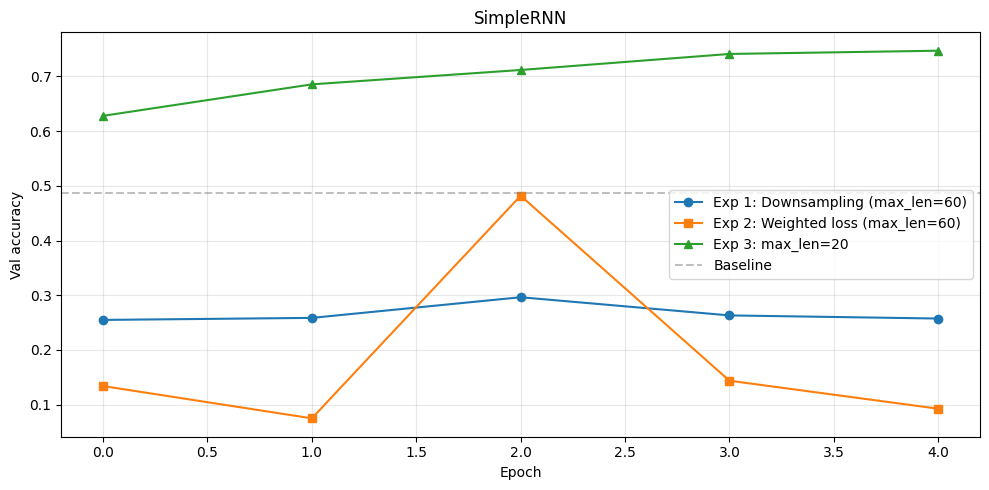


── Final val accuracy per experiment ──
  Exp 1 Downsampling only : 0.257
  Exp 2 Weighted loss only: 0.093
  Exp 3 max_len=20 only   : 0.747
  Baseline (always cls 1) : 0.487


In [101]:
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, sequences, labels):
        # sequences: numpy array of shape (N, max_len)
        # labels:    numpy array of shape (N,)
        self.sequences = sequences
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx],    dtype=torch.long)
        return x, y
EPOCHS     = 5
LR         = 3e-4
BATCH_SIZE = 32
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

le = LabelEncoder()
le.fit(df["category"])
num_classes = len(le.classes_)

def make_labels(frame):
    return le.transform(frame["category"])

def encode_seq(tokens, vocab, oov_idx=1):
    return [vocab.get(w, oov_idx) for w in tokens]

def build_vocab_from(frame, min_freq=2):
    all_tokens = [w for toks in frame["tokens"] for w in toks]
    counter    = Counter(all_tokens)
    vocab      = {"<PAD>": 0, "<OOV>": 1}
    for i, (w, c) in enumerate(
        sorted([(w,c) for w,c in counter.items() if c >= min_freq],
               key=lambda x: -x[1])
    ):
        vocab[w] = i + 2
    return vocab

def make_loaders(frame, vocab, max_len, batch_size=BATCH_SIZE):
    labels = make_labels(frame)
    seqs   = [encode_seq(t, vocab) for t in frame["tokens"]]
    x      = pad_sequences(seqs, maxlen=max_len, padding="post", truncating="post")
    y      = labels

    x_tr, x_tmp, y_tr, y_tmp = train_test_split(
        x, y, test_size=0.3, stratify=y, random_state=42)
    x_val, x_te, y_val, y_te = train_test_split(
        x_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

    tr  = DataLoader(TextDataset(x_tr,  y_tr),  batch_size=batch_size, shuffle=True)
    val = DataLoader(TextDataset(x_val, y_val), batch_size=batch_size)
    te  = DataLoader(TextDataset(x_te,  y_te),  batch_size=batch_size)
    return tr, val, te, y_tr

def compute_weights(y_train):
    counts = Counter(y_train)
    total  = sum(counts.values())
    w      = torch.zeros(num_classes)
    for lbl, cnt in counts.items():
        w[lbl] = total / (num_classes * cnt)
    return w

def run_experiment(name, train_loader, val_loader, vocab,
                   use_weighted_loss=False, weights=None):
    """Train one SimpleRNN and return per-epoch val_acc."""
    model = SimpleRNN(
        vocab_size  = len(vocab),
        embed_dim   = 128,
        hidden_size = 128,
        num_classes = num_classes
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = (nn.CrossEntropyLoss(weight=weights.to(DEVICE))
                 if use_weighted_loss and weights is not None
                 else nn.CrossEntropyLoss())
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5)

    val_accs = []
    print(f"\n{'='*55}")
    print(f"  Experiment: {name}")
    print(f"{'='*55}")

    for epoch in range(EPOCHS):
        # ── train ──────────────────────────────────────────────
        model.train()
        correct, total_n, loss_sum = 0, 0, 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            correct  += (out.argmax(1) == y_b).sum().item()
            total_n  += y_b.size(0)
            loss_sum += loss.item() * y_b.size(0)

        train_acc  = correct / total_n
        train_loss = loss_sum / total_n

        # ── validate ────────────────────────────────────────────
        model.eval()
        all_preds, all_labels, val_loss = [], [], 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out = model(X_b)
                val_loss += criterion(out, y_b).item() * y_b.size(0)
                all_preds.append(out.argmax(1).cpu().numpy())
                all_labels.append(y_b.cpu().numpy())

        all_preds  = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        val_loss   = val_loss / len(all_labels)
        val_acc    = (all_preds == all_labels).mean()
        val_accs.append(val_acc)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:02d} | train {train_acc:.3f} | "
              f"val {val_acc:.3f} | loss {val_loss:.4f}")

    # final report
    print(f"\nFinal classification report — {name}")
    print(classification_report(all_labels, all_preds,
                                target_names=le.classes_, digits=3))
    return val_accs


# ═══════════════════════════════════════════════════════════
# EXPERIMENT 1 — Downsampling only  (max_len=60, no weights)
# ═══════════════════════════════════════════════════════════
def downsample(frame, max_ratio=2.5):
    min_count = frame["category"].value_counts().min()
    cap       = int(min_count * max_ratio)
    parts = [grp.sample(n=min(len(grp), cap), random_state=42)
             for _, grp in frame.groupby("category")]
    return pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)

df_exp1   = downsample(df, max_ratio=2.5)
vocab_e1  = build_vocab_from(df_exp1)
tr1, val1, te1, y_tr1 = make_loaders(df_exp1, vocab_e1, max_len=60)
accs_exp1 = run_experiment(
    "Exp 1 — Downsampling only (max_len=60)",
    tr1, val1, vocab_e1,
    use_weighted_loss=False
)


# ═══════════════════════════════════════════════════════════
# EXPERIMENT 2 — Weighted loss only  (max_len=60, raw df)
# ═══════════════════════════════════════════════════════════
vocab_e2  = build_vocab_from(df)
tr2, val2, te2, y_tr2 = make_loaders(df, vocab_e2, max_len=60)
w2        = compute_weights(y_tr2)
accs_exp2 = run_experiment(
    "Exp 2 — Weighted loss only (max_len=60)",
    tr2, val2, vocab_e2,
    use_weighted_loss=True,
    weights=w2
)


# ═══════════════════════════════════════════════════════════
# EXPERIMENT 3 — max_len=20 only  (raw df, no weights)
# ═══════════════════════════════════════════════════════════
vocab_e3  = build_vocab_from(df)
tr3, val3, te3, y_tr3 = make_loaders(df, vocab_e3, max_len=20)
accs_exp3 = run_experiment(
    "Exp 3 — Short sequences only (max_len=20)",
    tr3, val3, vocab_e3,
    use_weighted_loss=False
)


# ═══════════════════════════════════════════════════════════
# COMPARISON PLOT
# ═══════════════════════════════════════════════════════════
plt.figure(figsize=(10, 5))
plt.plot(accs_exp1, marker='o', label="Exp 1: Downsampling (max_len=60)")
plt.plot(accs_exp2, marker='s', label="Exp 2: Weighted loss (max_len=60)")
plt.plot(accs_exp3, marker='^', label="Exp 3: max_len=20")
plt.axhline(y=0.487, color='gray', linestyle='--', alpha=0.5, label="Baseline")
plt.xlabel("Epoch")
plt.ylabel("Val accuracy")
plt.title("SimpleRNN")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# summary table
print("\n── Final val accuracy per experiment ──")
print(f"  Exp 1 Downsampling only : {accs_exp1[-1]:.3f}")
print(f"  Exp 2 Weighted loss only: {accs_exp2[-1]:.3f}")
print(f"  Exp 3 max_len=20 only   : {accs_exp3[-1]:.3f}")
print(f"  Baseline (always cls 1) : 0.487")